In [1]:
# ============================================================
# УСТАНОВКА ЗАВИСИМОСТЕЙ (запустить если нужно)
# ============================================================
# !pip install pandas numpy matplotlib seaborn scipy

In [20]:
# ============================================================
# ИМПОРТ БИБЛИОТЕК
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Библиотеки успешно импортированы.')
print(f'pandas {pd.__version__}, numpy {np.__version__}')

Библиотеки успешно импортированы.
pandas 3.0.1, numpy 2.4.3


In [21]:
# ============================================================
# ЗАГРУЗКА И ПЕРВИЧНАЯ ОЧИСТКА ДАННЫХ
# ============================================================

FILE_PATH = 'WB_SSGD_PCT_POP_INTERNET_USAGE.csv'
raw = pd.read_csv(FILE_PATH, low_memory=False)

print('Исходные столбцы:')
print(list(raw.columns))
print(f'\nРазмер сырого датасета: {raw.shape[0]} строк × {raw.shape[1]} столбцов')

# Оставляем только нужный индикатор и валидные числовые значения
raw = raw[raw['INDICATOR'] == 'WB_SSGD_PCT_POP_INTERNET_USAGE'].copy()
raw['year'] = pd.to_numeric(raw['TIME_PERIOD'], errors='coerce')
raw['internet_pct'] = pd.to_numeric(raw['OBS_VALUE'], errors='coerce')
raw = raw.dropna(subset=['year', 'internet_pct'])
raw['year'] = raw['year'].astype(int)

# Ключ подгруппы: именно на этих разрезах будем проверять полноту данных по стране
key_cols = ['SEX', 'AGE', 'URBANISATION', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2']
raw['subgroup'] = raw[key_cols].astype(str).agg('|'.join, axis=1)

# Набор обязательных подгрупп (полный профиль показателя внутри года)
required_subgroups = [
    'F|_T|_T|_T|_T',
    'M|_T|_T|_T|_T',
    '_T|Y15T24|_T|_T|_T',
    '_T|Y15T29|_T|_T|_T',
    '_T|Y30T59|_T|_T|_T',
    '_T|Y_GE25|_T|_T|_T',
    '_T|Y_GE60|_T|_T|_T',
    '_T|_T|RUR|_T|_T',
    '_T|_T|URB|_T|_T',
    '_T|_T|_T|WB_SSGD_ETHNICITY_1|_T',
    '_T|_T|_T|WB_SSGD_ETHNICITY_2|_T',
    '_T|_T|_T|_T|WB_SSGD_RELIGION_1',
    '_T|_T|_T|_T|WB_SSGD_RELIGION_2',
    '_T|_T|_T|_T|_T',
]
required_subgroups_set = set(required_subgroups)

# Для каждого года ищем страны, где есть полный набор required_subgroups
year_to_countries = {}
for y, g_year in raw.groupby('year'):
    good = []
    for country, g_country in g_year.groupby('REF_AREA_LABEL'):
        if required_subgroups_set.issubset(set(g_country['subgroup'])):
            good.append(country)
    if good:
        year_to_countries[y] = sorted(good)

if not year_to_countries:
    raise ValueError('Не найден ни один год со странами, имеющими полный required-набор данных.')

# Берем год с максимальным числом полных стран (автоматически)
target_year = max(year_to_countries, key=lambda y: len(year_to_countries[y]))
full_countries = year_to_countries[target_year]

# Берем 5 стран с полными данными
if len(full_countries) < 5:
    raise ValueError(f'В {target_year} найдено меньше 5 стран с полным набором данных: {full_countries}')
COUNTRIES = full_countries[:5]

# Полный пул данных (все полные страны выбранного года)
df_pool = raw[
    (raw['year'] == target_year)
    & (raw['REF_AREA_LABEL'].isin(full_countries))
    & (raw['subgroup'].isin(required_subgroups))
][['REF_AREA', 'REF_AREA_LABEL', 'year', 'subgroup', 'internet_pct']].copy()
df_pool.columns = ['code', 'country', 'year', 'subgroup', 'internet_pct']
df_pool.drop_duplicates(subset=['code', 'year', 'subgroup'], inplace=True)

# Рабочий датасет: 5 стран для анализа
df_all = df_pool[df_pool['country'].isin(COUNTRIES)].copy()
df_all.sort_values(['country', 'subgroup'], inplace=True)
df_all.reset_index(drop=True, inplace=True)

# Контроль полноты: в каждой стране должны быть все required_subgroups
coverage = df_all.groupby('country')['subgroup'].nunique().sort_values()
missing_report = {}
for country in COUNTRIES:
    observed = set(df_all[df_all['country'] == country]['subgroup'])
    missing = sorted(required_subgroups_set - observed)
    if missing:
        missing_report[country] = missing

print(f'\nГод анализа (автовыбор): {target_year}')
print(f'Стран с полным набором в этом году: {len(full_countries)}')
print(f'Выбранные 5 стран: {COUNTRIES}')
print(f'Размер df_pool: {df_pool.shape[0]} строк; размер df_all: {df_all.shape[0]} строк')
print('\nПокрытие подгрупп по выбранным странам:')
print(coverage.to_string())

if missing_report:
    raise ValueError(f'Есть страны с неполным набором данных: {missing_report}')

print('\nПроверка пройдена: у каждой выбранной страны полный required-набор, пропусков нет.')

Исходные столбцы:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']

Размер сырого датасета: 1432 строк × 40 столбцов

Год анализа (автовыбор): 2017
Стран с полным набором в этом году: 20
Выбранные 5 стран: ['Benin', 'Botswana', 'Burkina Faso', 'Cabo Verde', "Cote d'Ivoire"]
Размер df_pool: 280 строк; размер df_all: 70 строк

Покрытие подгрупп по выбранным странам:
country
Benin            14

In [22]:
# ============================================================
# === 1.1 === ВЫБОР КРИТЕРИЕВ И ДАННЫХ
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.1 — Выбор статистических критериев и данных')
print('=' * 65)

available = COUNTRIES.copy()
MAIN_3 = available[:3]

# Рабочий набор для тестов
df = df_all[df_all['country'].isin(available)].copy()

print(f'\nГод анализа: {target_year}')
print(f'Страны с полным набором данных в этом году: {len(full_countries)}')
print(f'Выбранные страны (5 шт.): {available}')
print(f'Рабочий размер выборки: {len(df)} наблюдений')

print("""
Выбранные статистические критерии (база на оценку "3"):
---------------------------------------------------------
1) t-test Стьюдента (независимые выборки)
2) Тест Манна-Уитни (U-test)
3) Критерий хи-квадрат (Chi-square)
4) Тест Шапиро-Уилка (Shapiro-Wilk, проверка предпосылок)

Дополнительно (на 4-5):
5) Однофакторный ANOVA + post-hoc (Бонферрони)

Дополнительные данные, связанные с ПР №1:
- Помимо общего индикатора Total используются разрезы внутри страны:
  пол, возраст, урбанизация, этничность, религиозные группы.
- Это расширяет исходные данные ПР №1 и позволяет применять
  критерии к нескольким независимым выборкам без временных рядов.

Важно:
- Здесь НЕТ анализа временных рядов
- Анализ кросс-секционный: сравнение стран внутри одного года
""")

РАЗДЕЛ 1.1 — Выбор статистических критериев и данных

Год анализа: 2017
Страны с полным набором данных в этом году: 20
Выбранные страны (5 шт.): ['Benin', 'Botswana', 'Burkina Faso', 'Cabo Verde', "Cote d'Ivoire"]
Рабочий размер выборки: 70 наблюдений

Выбранные статистические критерии (база на оценку "3"):
---------------------------------------------------------
1) t-test Стьюдента (независимые выборки)
2) Тест Манна-Уитни (U-test)
3) Критерий хи-квадрат (Chi-square)
4) Тест Шапиро-Уилка (Shapiro-Wilk, проверка предпосылок)

Дополнительно (на 4-5):
5) Однофакторный ANOVA + post-hoc (Бонферрони)

Дополнительные данные, связанные с ПР №1:
- Помимо общего индикатора Total используются разрезы внутри страны:
  пол, возраст, урбанизация, этничность, религиозные группы.
- Это расширяет исходные данные ПР №1 и позволяет применять
  критерии к нескольким независимым выборкам без временных рядов.

Важно:
- Здесь НЕТ анализа временных рядов
- Анализ кросс-секционный: сравнение стран внутри одн

In [23]:
# ============================================================
# === 1.2 === ОПИСАНИЕ ДАННЫХ
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.2 — Описание источника данных')
print('=' * 65)

print("""
Источники и ссылки на таблицы данных:
1) Основная таблица (CSV в проекте):
   WB_SSGD_PCT_POP_INTERNET_USAGE.csv
2) Описание индикатора (World Bank Data360):
   https://data360.worldbank.org/en/indicator/WB_SSGD_PCT_POP_INTERNET_USAGE
3) База данных: WB_SSGD — Social Sustainability Global Database

Что берём из таблицы:
- INDICATOR = WB_SSGD_PCT_POP_INTERNET_USAGE
- TIME_PERIOD -> year
- OBS_VALUE -> internet_pct
- REF_AREA / REF_AREA_LABEL -> код и название страны
- Разрезы: SEX, AGE, URBANISATION, COMP_BREAKDOWN_1, COMP_BREAKDOWN_2

Что фактически означают данные:
- Показатель: доля населения, использующего интернет, в процентах.
- Единицы измерения: % населения.
- Тип переменной: количественная, непрерывная (RATIO).

Какие подготовленные таблицы используются в исследовании:
- raw: очищенные исходные данные из CSV
- df_pool: полный пул стран с полным профилем подгрупп в выбранном году
- df: рабочая таблица 5 стран для статистических тестов
- ct / expected_df: таблица сопряженности и ожидаемые частоты для χ²
""")

print('Статистика по подготовленному датасету:')
print(f'  Год анализа                  : {target_year}')
print(f'  Обязательных подгрупп        : {len(required_subgroups)}')
print(f'  Полных стран в этом году     : {len(full_countries)}')
print(f'  Выбрано стран для анализа    : {len(available)}')
print(f'  Всего наблюдений             : {len(df)}')
print(f'  Мин. значение (%)            : {df["internet_pct"].min():.2f}')
print(f'  Макс. значение (%)           : {df["internet_pct"].max():.2f}')
print(f'  Среднее (%)                  : {df["internet_pct"].mean():.2f}')
print(f'  Медиана (%)                  : {df["internet_pct"].median():.2f}')

print('\nВыбранные страны для анализа:')
for c in available:
    sub = df[df['country'] == c]
    print(f'  {c:20s}: {len(sub)} наблюдений, среднее {sub["internet_pct"].mean():.2f}%, '
          f'медиана {sub["internet_pct"].median():.2f}%')

РАЗДЕЛ 1.2 — Описание источника данных

Источники и ссылки на таблицы данных:
1) Основная таблица (CSV в проекте):
   WB_SSGD_PCT_POP_INTERNET_USAGE.csv
2) Описание индикатора (World Bank Data360):
   https://data360.worldbank.org/en/indicator/WB_SSGD_PCT_POP_INTERNET_USAGE
3) База данных: WB_SSGD — Social Sustainability Global Database

Что берём из таблицы:
- INDICATOR = WB_SSGD_PCT_POP_INTERNET_USAGE
- TIME_PERIOD -> year
- OBS_VALUE -> internet_pct
- REF_AREA / REF_AREA_LABEL -> код и название страны
- Разрезы: SEX, AGE, URBANISATION, COMP_BREAKDOWN_1, COMP_BREAKDOWN_2

Что фактически означают данные:
- Показатель: доля населения, использующего интернет, в процентах.
- Единицы измерения: % населения.
- Тип переменной: количественная, непрерывная (RATIO).

Какие подготовленные таблицы используются в исследовании:
- raw: очищенные исходные данные из CSV
- df_pool: полный пул стран с полным профилем подгрупп в выбранном году
- df: рабочая таблица 5 стран для статистических тестов
- ct

In [24]:
# ============================================================
# === 1.3 === ФОРМАЛЬНОЕ ПРЕДСТАВЛЕНИЕ ДАННЫХ
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.3 — Формальное представление датасета')
print('=' * 65)

print(f'\nРазмер рабочего датасета: {df.shape[0]} строк × {df.shape[1]} столбцов')
print()

print('--- Первые 10 строк (head) ---')
print(df.head(10).to_string(index=False))

print('\n--- Последние 10 строк (tail) ---')
print(df.tail(10).to_string(index=False))

print('\n--- Описательная статистика по странам ---')
desc = df.groupby('country')['internet_pct'].describe().round(2)
print(desc.to_string())

print('\n--- Проверка пропусков ---')
print(df.isnull().sum())

print('\n--- Проверка полноты подгрупп по странам ---')
coverage_matrix = pd.crosstab(df['country'], df['subgroup'])
print(f'Матрица покрытия: {coverage_matrix.shape[0]} стран × {coverage_matrix.shape[1]} подгрупп')
print('Минимум наблюдений в ячейке:', int(coverage_matrix.min().min()))
print('Максимум наблюдений в ячейке:', int(coverage_matrix.max().max()))

if df.isnull().sum().sum() == 0 and coverage_matrix.min().min() >= 1:
    print('Проверка пройдена: пустых данных нет, все необходимые подгруппы присутствуют.')
else:
    print('ВНИМАНИЕ: обнаружены пропуски или неполное покрытие подгрупп.')

РАЗДЕЛ 1.3 — Формальное представление датасета

Размер рабочего датасета: 70 строк × 5 столбцов

--- Первые 10 строк (head) ---
code country  year                        subgroup  internet_pct
 BEN   Benin  2017                   F|_T|_T|_T|_T      9.772684
 BEN   Benin  2017                   M|_T|_T|_T|_T     32.489864
 BEN   Benin  2017              _T|Y15T24|_T|_T|_T     34.260132
 BEN   Benin  2017              _T|Y15T29|_T|_T|_T     31.190392
 BEN   Benin  2017              _T|Y30T59|_T|_T|_T     15.820113
 BEN   Benin  2017              _T|Y_GE25|_T|_T|_T     17.078152
 BEN   Benin  2017              _T|Y_GE60|_T|_T|_T      3.171166
 BEN   Benin  2017                 _T|_T|RUR|_T|_T     12.258126
 BEN   Benin  2017                 _T|_T|URB|_T|_T     30.903084
 BEN   Benin  2017 _T|_T|_T|WB_SSGD_ETHNICITY_1|_T     26.399118

--- Последние 10 строк (tail) ---
code       country  year                        subgroup  internet_pct
 CIV Cote d'Ivoire  2017              _T|Y30T59|_T|

РАЗДЕЛ 1.4 — Визуализация данных (кросс-секционный анализ)


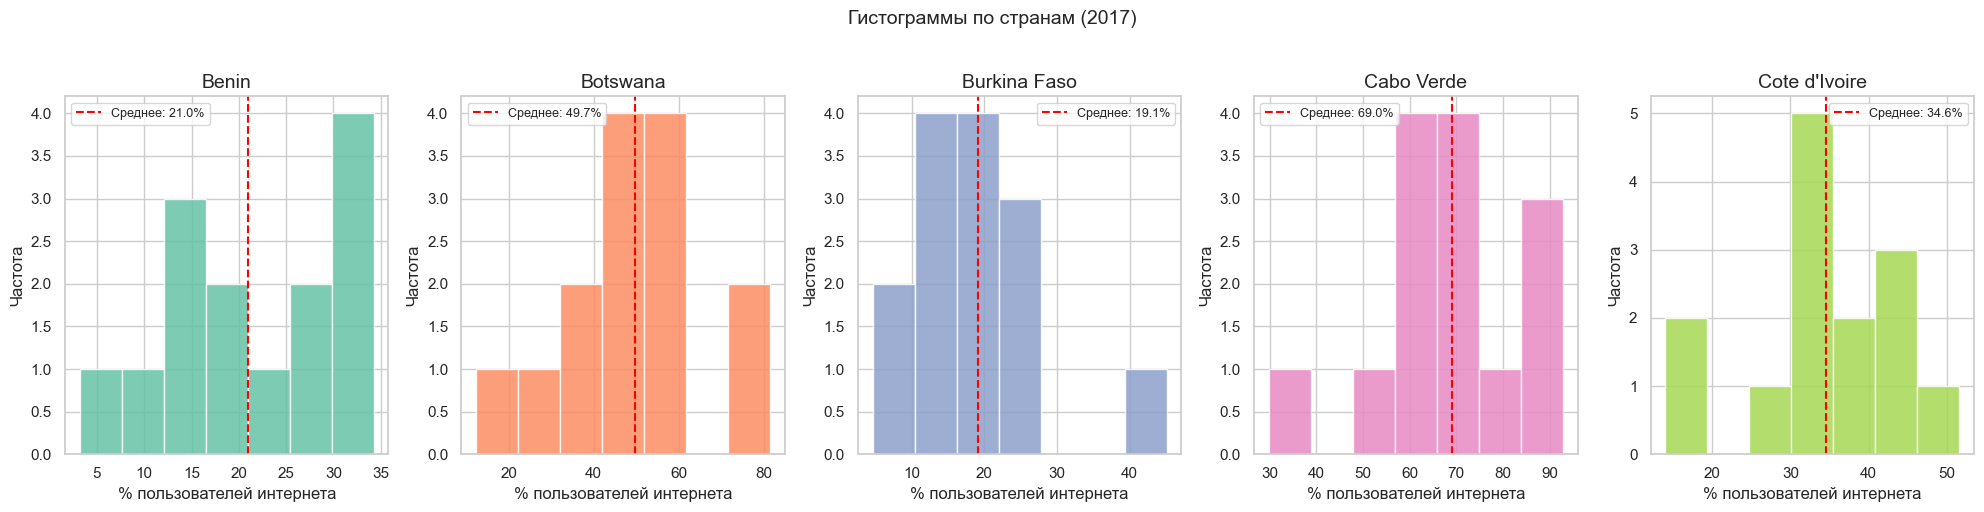

График 1: Гистограммы показывают распределение по подгруппам внутри каждой страны.


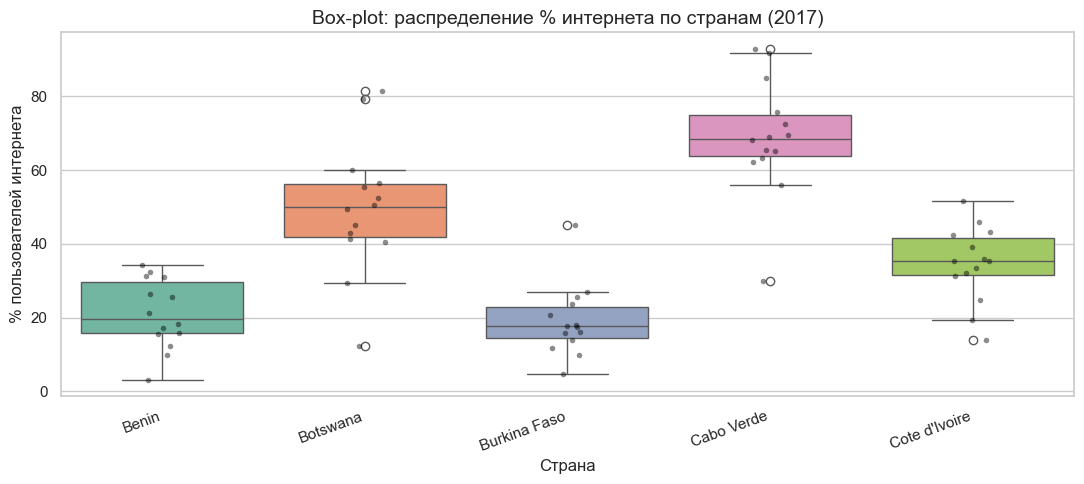

График 2: Box-plot сравнивает медианы, квартильные интервалы и разброс по странам.


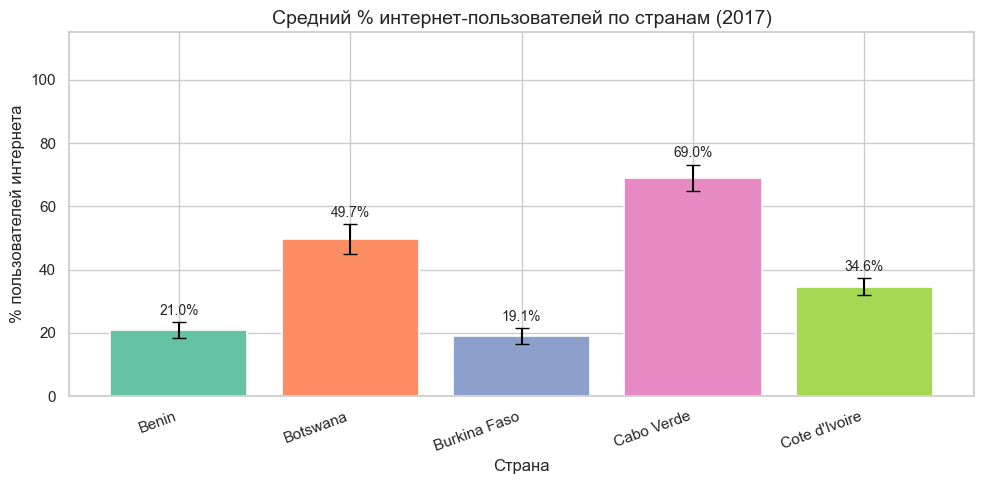

График 3: Столбчатая диаграмма сравнивает средний уровень по странам (с SEM).


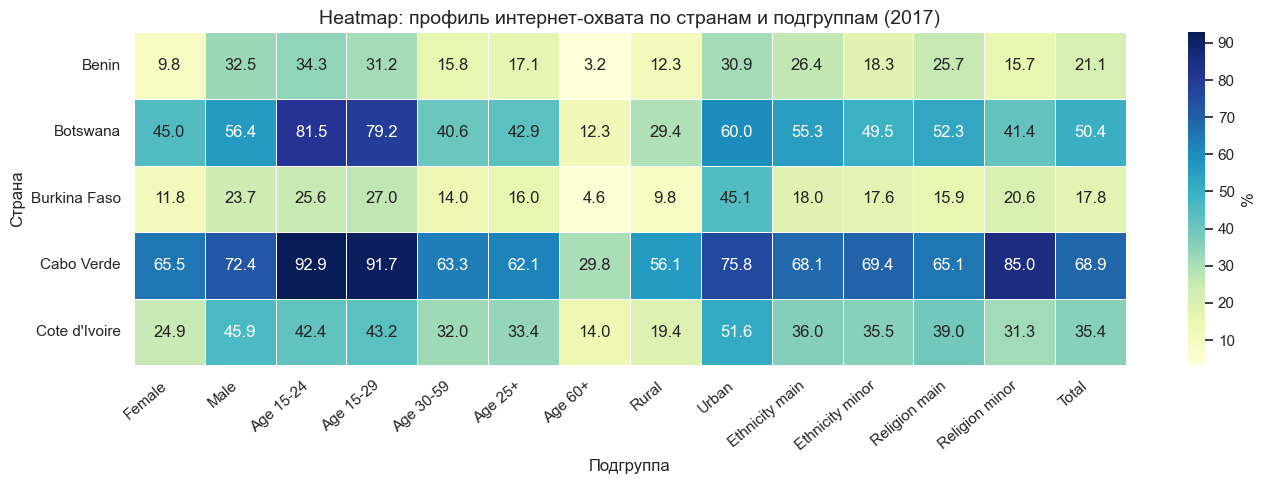

График 4: Heatmap показывает, какие подгруппы дают наибольший вклад по каждой стране.


In [7]:
# ============================================================
# === 1.4 === ВИЗУАЛИЗАЦИЯ
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.4 — Визуализация данных (кросс-секционный анализ)')
print('=' * 65)

colors = sns.color_palette('Set2', n_colors=len(available))
country_color = {c: colors[i] for i, c in enumerate(available)}

subgroup_name = {
    'F|_T|_T|_T|_T': 'Female',
    'M|_T|_T|_T|_T': 'Male',
    '_T|Y15T24|_T|_T|_T': 'Age 15-24',
    '_T|Y15T29|_T|_T|_T': 'Age 15-29',
    '_T|Y30T59|_T|_T|_T': 'Age 30-59',
    '_T|Y_GE25|_T|_T|_T': 'Age 25+',
    '_T|Y_GE60|_T|_T|_T': 'Age 60+',
    '_T|_T|RUR|_T|_T': 'Rural',
    '_T|_T|URB|_T|_T': 'Urban',
    '_T|_T|_T|WB_SSGD_ETHNICITY_1|_T': 'Ethnicity main',
    '_T|_T|_T|WB_SSGD_ETHNICITY_2|_T': 'Ethnicity minor',
    '_T|_T|_T|_T|WB_SSGD_RELIGION_1': 'Religion main',
    '_T|_T|_T|_T|WB_SSGD_RELIGION_2': 'Religion minor',
    '_T|_T|_T|_T|_T': 'Total',
}

# ---- 1. Гистограммы распределений по странам ----
fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 5), sharey=False)
if len(available) == 1:
    axes = [axes]
for ax, country in zip(axes, available):
    vals = df[df['country'] == country]['internet_pct']
    ax.hist(vals, bins=7, color=country_color[country], edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {vals.mean():.1f}%')
    ax.set_title(country)
    ax.set_xlabel('% пользователей интернета')
    ax.set_ylabel('Частота')
    ax.legend(fontsize=9)
fig.suptitle(f'Гистограммы по странам ({target_year})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_histogram.png', dpi=120, bbox_inches='tight')
plt.show()
print('График 1: Гистограммы показывают распределение по подгруппам внутри каждой страны.')

# ---- 2. Box-plot по странам ----
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='country', y='internet_pct', palette='Set2', ax=ax)
sns.stripplot(data=df, x='country', y='internet_pct', color='black', alpha=0.45, size=4, ax=ax)
ax.set_title(f'Box-plot: распределение % интернета по странам ({target_year})')
ax.set_xlabel('Страна')
ax.set_ylabel('% пользователей интернета')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plot_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('График 2: Box-plot сравнивает медианы, квартильные интервалы и разброс по странам.')

# ---- 3. Средние значения по странам ----
mean_stats = df.groupby('country')['internet_pct'].agg(['mean', 'std', 'count']).reset_index()
mean_stats['sem'] = mean_stats['std'] / np.sqrt(mean_stats['count'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    mean_stats['country'],
    mean_stats['mean'],
    yerr=mean_stats['sem'],
    capsize=5,
    color=[country_color[c] for c in mean_stats['country']],
    edgecolor='white',
    linewidth=1.2,
)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_title(f'Средний % интернет-пользователей по странам ({target_year})')
ax.set_xlabel('Страна')
ax.set_ylabel('% пользователей интернета')
ax.set_ylim(0, 115)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plot_country_means.png', dpi=120, bbox_inches='tight')
plt.show()
print('График 3: Столбчатая диаграмма сравнивает средний уровень по странам (с SEM).')

# ---- 4. Heatmap: страна × подгруппа ----
heat = df.pivot_table(index='country', columns='subgroup', values='internet_pct', aggfunc='mean')
heat = heat[required_subgroups]
heat.columns = [subgroup_name.get(c, c) for c in heat.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': '%'})
ax.set_title(f'Heatmap: профиль интернет-охвата по странам и подгруппам ({target_year})')
ax.set_xlabel('Подгруппа')
ax.set_ylabel('Страна')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('График 4: Heatmap показывает, какие подгруппы дают наибольший вклад по каждой стране.')

In [8]:
# ============================================================
# === 1.5 === ОПИСАНИЕ КРИТЕРИЕВ
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.5 — Описание статистических критериев')
print('=' * 65)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
КРИТЕРИЙ 1: Тест Шапиро-Уилка (Shapiro-Wilk)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Для чего: проверка нормальности распределения в каждой группе.

Формула:
W = (sum(a_i * x_(i)))^2 / sum((x_i - x_mean)^2)

Условия применения:
- Данные количественные
- 3 <= n <= 5000 для каждой проверяемой группы

Объём выборок в работе:
- По каждой стране: n = 14

Гипотезы:
H0: выборка имеет нормальное распределение
H1: выборка не имеет нормального распределения

Python (подробно):
stats.shapiro(x)
- x: одномерный массив наблюдений
- Возвращает: statistic (W), pvalue
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
КРИТЕРИЙ 2: t-тест Стьюдента (независимые выборки, Welch)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Для чего: сравнение средних двух независимых групп.

Формула:
t = (x1_mean - x2_mean) / sqrt(s1^2/n1 + s2^2/n2)

Условия применения:
- Две независимые выборки
- Количественные данные
- Желательна нормальность (проверяем Шапиро)
- Для неравных дисперсий используем вариант Уэлча

Объём выборок в работе:
- Страна A: n = 14
- Страна B: n = 14

Гипотезы:
H0: mu1 = mu2
H1: mu1 != mu2

Python (подробно):
stats.ttest_ind(a, b, equal_var=False)
- a, b: массивы двух групп
- equal_var=False: Welch t-test (без предположения равенства дисперсий)
- Возвращает: statistic (t), pvalue
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
КРИТЕРИЙ 3: Тест Манна-Уитни (Mann-Whitney U)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Для чего: непараметрическое сравнение двух независимых групп.

Формула (через ранги):
U1 = n1*n2 + n1*(n1+1)/2 - R1
где R1 — сумма рангов 1-й группы.

Условия применения:
- Две независимые выборки
- Данные минимум порядковые
- Не требует нормальности

Объём выборок в работе:
- Страна A: n = 14
- Страна B: n = 14

Гипотезы:
H0: распределения двух групп одинаковы
H1: распределения различаются

Python (подробно):
stats.mannwhitneyu(x, y, alternative='two-sided')
- x, y: массивы двух групп
- alternative='two-sided': двусторонняя проверка
- Возвращает: statistic (U), pvalue
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
КРИТЕРИЙ 4: Хи-квадрат Пирсона (χ²) на таблице сопряжённости
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Для чего: проверка зависимости между двумя категориальными признаками.
В работе: страна × категория охвата интернетом.

Формула:
chi2 = sum((O_ij - E_ij)^2 / E_ij)

Условия применения:
- Категориальные данные
- Независимые наблюдения
- Ожидаемые частоты желательно >= 5 в каждой ячейке

Объём выборок в работе:
- 5 стран, по 14 наблюдений в каждой
- После категоризации формируется таблица сопряженности

Гипотезы:
H0: категория охвата не зависит от страны
H1: категория охвата зависит от страны

Python (подробно):
stats.chi2_contingency(observed)
- observed: таблица сопряженности (DataFrame или массив)
- Возвращает: chi2, pvalue, dof, expected
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ДОПОЛНИТЕЛЬНО (2.2): Однофакторный ANOVA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Для чего: сравнение средних в 3+ независимых группах.

Формула:
F = MS_between / MS_within

Условия применения:
- 3 и более независимых групп
- Количественные данные
- Нормальность по группам (ориентировочно)
- Однородность дисперсий (проверяем тестом Левена)

Гипотезы:
H0: mu1 = mu2 = ... = muk
H1: хотя бы одно среднее отличается

Python (подробно):
stats.f_oneway(group1, group2, ..., groupk)
- Возвращает: statistic (F), pvalue
""")

print('\nВажно: анализ кросс-секционный (один год), без исследования временных рядов.')

РАЗДЕЛ 1.5 — Описание статистических критериев

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
КРИТЕРИЙ 1: Тест Шапиро-Уилка (Shapiro-Wilk)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Для чего: проверка нормальности распределения в каждой группе.

Формула:
W = (sum(a_i * x_(i)))^2 / sum((x_i - x_mean)^2)

Условия применения:
- Данные количественные
- 3 <= n <= 5000 для каждой проверяемой группы

Объём выборок в работе:
- По каждой стране: n = 14

Гипотезы:
H0: выборка имеет нормальное распределение
H1: выборка не имеет нормального распределения

Python (подробно):
stats.shapiro(x)
- x: одномерный массив наблюдений
- Возвращает: statistic (W), pvalue


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
КРИТЕРИЙ 2: t-тест Стьюдента (независимые выборки, Welch)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Для чего: сравнение средних двух независимых групп.

Формула:
t = (x1_mean - x2_mean) / sqrt(s1^2/n1 + s2^2/n2)

Условия 

РАЗДЕЛ 2.1 — Шаг 1: Проверка нормальности (Shapiro-Wilk)

Уровень значимости α = 0.05
Страна                     n   W-статистика      p-value    Нормальность
---------------------------------------------------------------------------
Benin                     14         0.9548       0.6367            ДА ✓
Botswana                  14         0.9504       0.5675            ДА ✓
Burkina Faso              14         0.8949       0.0950            ДА ✓
Cabo Verde                14         0.9092       0.1532            ДА ✓
Cote d'Ivoire             14         0.9697       0.8728            ДА ✓

Интерпретация:
  Если p > 0.05 → не отвергаем H0 → данные нормально распределены
  Если p < 0.05 → отвергаем H0 → распределение НЕ нормальное


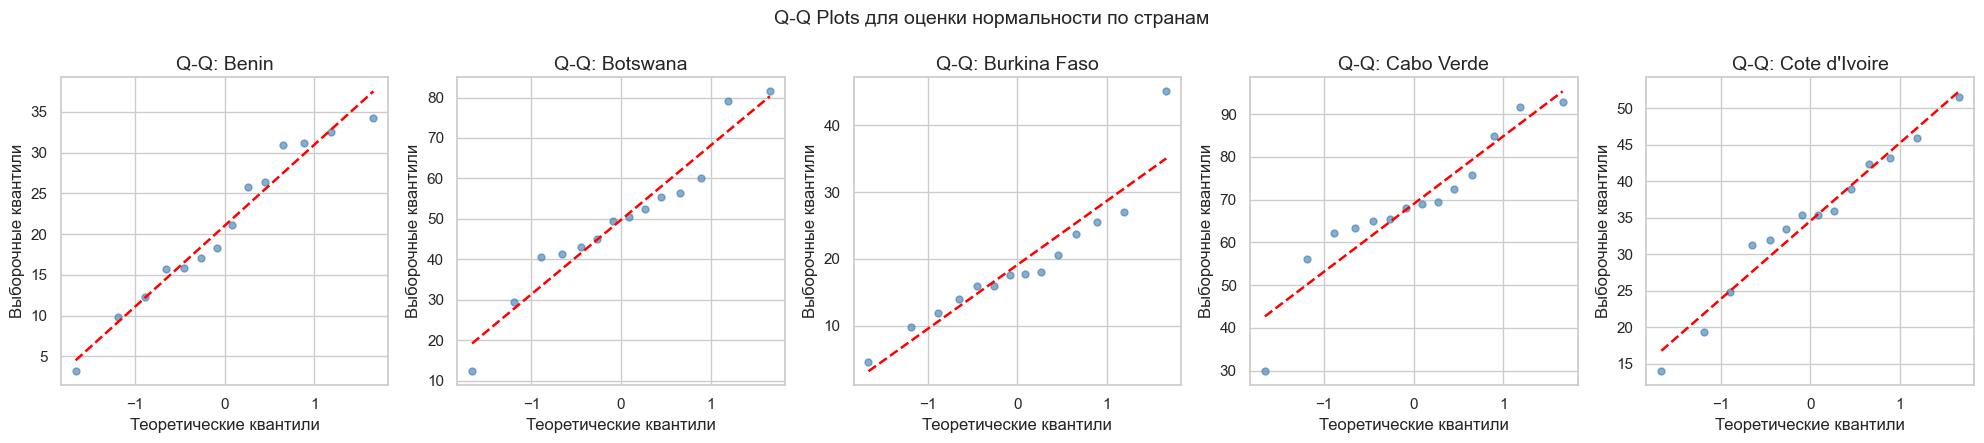


Q-Q plot: точки, близкие к линии, указывают на близость к нормальному распределению.


In [9]:
# ============================================================
# === 2.1 === ПОСЛЕДОВАТЕЛЬНОЕ ПРИМЕНЕНИЕ ТЕСТОВ
# Шаг 1: Проверка нормальности (Шапиро-Уилк)
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 2.1 — Шаг 1: Проверка нормальности (Shapiro-Wilk)')
print('=' * 65)

normality_results = {}

print(f'\nУровень значимости α = 0.05')
print(f'{"Страна":<22} {"n":>5} {"W-статистика":>14} {"p-value":>12} {"Нормальность":>15}')
print('-' * 75)

for country in available:
    vals = df[df['country'] == country]['internet_pct'].dropna().values
    if len(vals) < 3:
        print(f'{country:<22} {len(vals):>5} {"мало данных":>14}')
        normality_results[country] = None
        continue

    stat, p = stats.shapiro(vals)
    is_normal = p > 0.05
    normality_results[country] = is_normal
    verdict = 'ДА ✓' if is_normal else 'НЕТ ✗'
    print(f'{country:<22} {len(vals):>5} {stat:>14.4f} {p:>12.4f} {verdict:>15}')

print()
print('Интерпретация:')
print('  Если p > 0.05 → не отвергаем H0 → данные нормально распределены')
print('  Если p < 0.05 → отвергаем H0 → распределение НЕ нормальное')

# Q-Q plots по каждой стране
fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 4.5))
if len(available) == 1:
    axes = [axes]

for ax, country in zip(axes, available):
    pdata = df[df['country'] == country]['internet_pct'].dropna().values
    (osm, osr), (slope, intercept, r) = stats.probplot(pdata, dist='norm')
    ax.plot(osm, osr, 'o', alpha=0.65, color='steelblue', markersize=5)
    ax.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.8)
    ax.set_title(f'Q-Q: {country}')
    ax.set_xlabel('Теоретические квантили')
    ax.set_ylabel('Выборочные квантили')

fig.suptitle('Q-Q Plots для оценки нормальности по странам', fontsize=14)
plt.tight_layout()
plt.savefig('plot_qqplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nQ-Q plot: точки, близкие к линии, указывают на близость к нормальному распределению.')

In [10]:
# ============================================================
# === 1.6 / 2.1 === Шаг 2: t-тест Стьюдента
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.6 — Тест 1: t-тест Стьюдента (две страны)')
print('=' * 65)

if len(available) < 2:
    raise ValueError('Для t-теста нужно минимум 2 страны в выборке.')

country_a, country_b = available[0], available[1]
group_a = df[df['country'] == country_a]['internet_pct'].dropna().values
group_b = df[df['country'] == country_b]['internet_pct'].dropna().values

print(f'\nСравниваем страны: {country_a} vs {country_b}')
print(f'Группа 1 ({country_a}): n={len(group_a)}, среднее={group_a.mean():.2f}%, std={group_a.std():.2f}%')
print(f'Группа 2 ({country_b}): n={len(group_b)}, среднее={group_b.mean():.2f}%, std={group_b.std():.2f}%')

t_stat, t_p = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f'\nРезультат t-теста Уэлча (Welch):')
print(f'  t-статистика : {t_stat:.4f}')
print(f'  p-value      : {t_p:.6f}')
print()
if t_p < 0.05:
    print(f'  p = {t_p:.6f} < 0.05 → ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Средние значения в двух странах статистически значимо различаются.')
else:
    print(f'  p = {t_p:.6f} ≥ 0.05 → НЕ ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Значимых различий между средними не обнаружено.')

РАЗДЕЛ 1.6 — Тест 1: t-тест Стьюдента (две страны)

Сравниваем страны: Benin vs Botswana
Группа 1 (Benin): n=14, среднее=21.01%, std=9.10%
Группа 2 (Botswana): n=14, среднее=49.74%, std=17.11%

Результат t-теста Уэлча (Welch):
  t-статистика : -5.3439
  p-value      : 0.000032

  p = 0.000032 < 0.05 → ОТВЕРГАЕМ H0
  ВЫВОД: Средние значения в двух странах статистически значимо различаются.


In [11]:
# ============================================================
# === 1.6 / 2.1 === Шаг 3: Тест Манна-Уитни
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.6 — Тест 2: Тест Манна-Уитни (две страны)')
print('=' * 65)

u_stat, u_p = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')

print(f'\nСравниваем страны: {country_a} vs {country_b}')
print(f'Группа 1 ({country_a}): n={len(group_a)}, медиана={np.median(group_a):.2f}%')
print(f'Группа 2 ({country_b}): n={len(group_b)}, медиана={np.median(group_b):.2f}%')

print(f'\nРезультат теста Манна-Уитни:')
print(f'  U-статистика : {u_stat:.2f}')
print(f'  p-value      : {u_p:.6f}')
print()
if u_p < 0.05:
    print(f'  p = {u_p:.6f} < 0.05 → ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Распределения в двух странах статистически значимо различаются.')
else:
    print(f'  p = {u_p:.6f} ≥ 0.05 → НЕ ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Статистически значимых различий не обнаружено.')

print('\nСравнение с t-тестом:')
print(f'  t-тест: p={t_p:.6f}, Mann-Whitney: p={u_p:.6f}')
agree = (t_p < 0.05) == (u_p < 0.05)
print(f'  Оба теста дают {"СОГЛАСОВАННЫЙ" if agree else "НЕСОГЛАСОВАННЫЙ"} результат.')

РАЗДЕЛ 1.6 — Тест 2: Тест Манна-Уитни (две страны)

Сравниваем страны: Benin vs Botswana
Группа 1 (Benin): n=14, медиана=19.72%
Группа 2 (Botswana): n=14, медиана=49.93%

Результат теста Манна-Уитни:
  U-статистика : 15.00
  p-value      : 0.000150

  p = 0.000150 < 0.05 → ОТВЕРГАЕМ H0
  ВЫВОД: Распределения в двух странах статистически значимо различаются.

Сравнение с t-тестом:
  t-тест: p=0.000032, Mann-Whitney: p=0.000150
  Оба теста дают СОГЛАСОВАННЫЙ результат.


РАЗДЕЛ 1.6 — Тест 3: Критерий χ² (хи-квадрат)

Таблица сопряжённости (страна × категория охвата, 3 категории):
category       Низкий (<40%)  Средний (40-75%)  Высокий (>75%)
country                                                       
Benin                     14                 0               0
Botswana                   2                10               2
Burkina Faso              13                 1               0
Cabo Verde                 1                 9               4
Cote d'Ivoire             10                 4               0

Минимальная ожидаемая частота (3 категории): 1.2

Условие χ² нарушено: есть ожидаемые частоты < 5.
Выполняем укрупнение категорий до 2 уровней: <40% и >=40%.

Итоговая таблица сопряжённости для χ²:
category       Низкий (<40%)  Средний+Высокий (>=40%)
country                                              
Benin                     14                        0
Botswana                   2                       12
Burkina Faso              13     

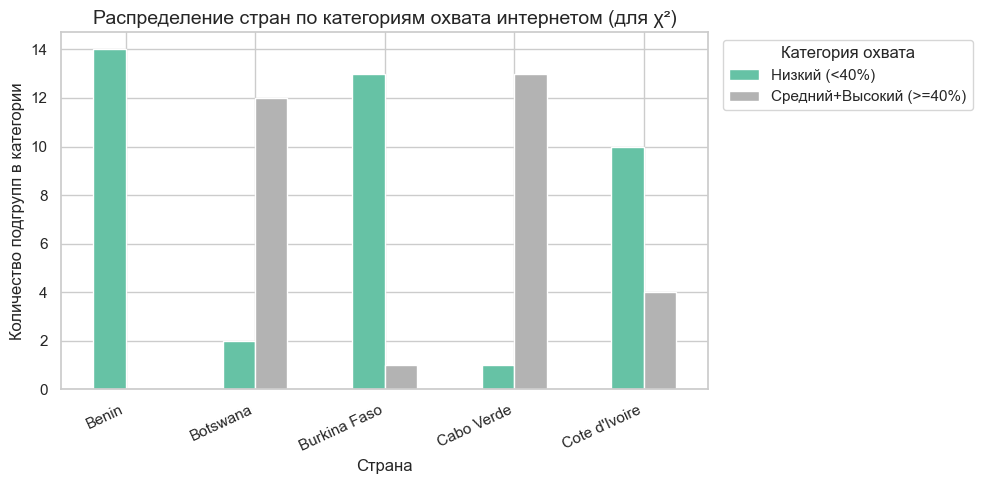


График: число подгрупп в каждой категории охвата по странам (итоговая схема категорий).


In [12]:
# ============================================================
# === 1.6 === Тест 3: Критерий χ² (хи-квадрат)
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.6 — Тест 3: Критерий χ² (хи-квадрат)')
print('=' * 65)

df_chi = df.copy()

# Базовая категоризация: 3 категории
bins3 = [-1, 40, 75, 101]
labels3 = ['Низкий (<40%)', 'Средний (40-75%)', 'Высокий (>75%)']
df_chi['category'] = pd.cut(df_chi['internet_pct'], bins=bins3, labels=labels3)

ct = pd.crosstab(df_chi['country'], df_chi['category'])
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(ct)
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2)

print('\nТаблица сопряжённости (страна × категория охвата, 3 категории):')
print(ct.to_string())
print('\nМинимальная ожидаемая частота (3 категории):', expected.min().round(3))

# Проверяем условие применимости χ². Если нарушено, укрупняем категории.
if expected.min() < 5:
    print('\nУсловие χ² нарушено: есть ожидаемые частоты < 5.')
    print('Выполняем укрупнение категорий до 2 уровней: <40% и >=40%.')

    bins2 = [-1, 40, 101]
    labels2 = ['Низкий (<40%)', 'Средний+Высокий (>=40%)']
    df_chi['category'] = pd.cut(df_chi['internet_pct'], bins=bins2, labels=labels2)

    ct = pd.crosstab(df_chi['country'], df_chi['category'])
    chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(ct)
    expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2)

print('\nИтоговая таблица сопряжённости для χ²:')
print(ct.to_string())

print(f'\nРезультат χ²-теста:')
print(f'  χ²-статистика  : {chi2_stat:.4f}')
print(f'  p-value        : {chi2_p:.6f}')
print(f'  Степени свободы: {dof}')
print('\nОжидаемые частоты:')
print(expected_df.to_string())
print(f'\nМинимальная ожидаемая частота (итог): {expected.min():.3f}')

if chi2_p < 0.05:
    print(f'  p = {chi2_p:.6f} < 0.05 → ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Распределение категорий охвата статистически значимо')
    print('  различается между странами.')
else:
    print(f'  p = {chi2_p:.6f} ≥ 0.05 → НЕ ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Зависимость между страной и категорией охвата не выявлена.')

# Визуализация итоговой таблицы сопряжённости
fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Распределение стран по категориям охвата интернетом (для χ²)')
ax.set_xlabel('Страна')
ax.set_ylabel('Количество подгрупп в категории')
ax.legend(title='Категория охвата', bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.savefig('plot_chi2.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nГрафик: число подгрупп в каждой категории охвата по странам (итоговая схема категорий).')

РАЗДЕЛ 2.2 — Тест 4: Однофакторный ANOVA

Описательная статистика по группам (странам):
Страна                     n    Среднее    Медиана        Std
----------------------------------------------------------------
Benin                     14      21.01      19.72       9.10
Botswana                  14      49.74      49.93      17.11
Burkina Faso              14      19.11      17.69       9.26
Cabo Verde                14      69.00      68.53      15.13
Cote d'Ivoire             14      34.57      35.44       9.80

Тест Левена (гомогенность дисперсий): stat=1.0953, p=0.3664
  Дисперсии однородны → ANOVA применимо.

Результат ANOVA:
  F-статистика : 36.2488
  p-value      : 0.000000

  p = 0.000000 < 0.05 → ОТВЕРГАЕМ H0
  ВЫВОД: Средний % интернет-пользователей статистически значимо
  различается хотя бы между одной парой стран.

--- Post-hoc: Попарные сравнения (t-тест с поправкой Бонферрони) ---
Пара стран                                       t-stat      p (raw)     p (Bonf)    

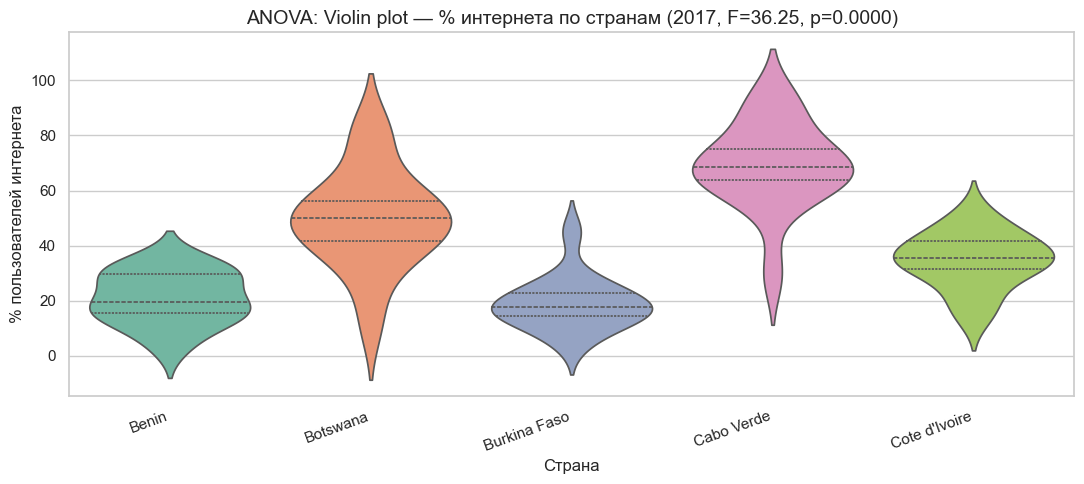


Violin plot: форма скрипки показывает распределение значений для каждой страны.


In [13]:
# ============================================================
# === 2.2 === ДОПОЛНИТЕЛЬНЫЙ ТЕСТ: ANOVA
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 2.2 — Тест 4: Однофакторный ANOVA')
print('=' * 65)

groups_anova = [df[df['country'] == c]['internet_pct'].dropna().values for c in available]

print('\nОписательная статистика по группам (странам):')
print(f'{"Страна":<22} {"n":>5} {"Среднее":>10} {"Медиана":>10} {"Std":>10}')
print('-' * 64)
for country, g in zip(available, groups_anova):
    print(f'{country:<22} {len(g):>5} {g.mean():>10.2f} {np.median(g):>10.2f} {g.std():>10.2f}')

# Тест Левена — гомогенность дисперсий
levene_stat, levene_p = stats.levene(*groups_anova)
print(f'\nТест Левена (гомогенность дисперсий): stat={levene_stat:.4f}, p={levene_p:.4f}')
if levene_p > 0.05:
    print('  Дисперсии однородны → ANOVA применимо.')
else:
    print('  Дисперсии НЕ однородны → интерпретируем ANOVA осторожно.')

# ANOVA
f_stat, anova_p = stats.f_oneway(*groups_anova)

print(f'\nРезультат ANOVA:')
print(f'  F-статистика : {f_stat:.4f}')
print(f'  p-value      : {anova_p:.6f}')
print()
if anova_p < 0.05:
    print(f'  p = {anova_p:.6f} < 0.05 → ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Средний % интернет-пользователей статистически значимо')
    print('  различается хотя бы между одной парой стран.')
else:
    print(f'  p = {anova_p:.6f} ≥ 0.05 → НЕ ОТВЕРГАЕМ H0')
    print('  ВЫВОД: Значимых различий между средними не обнаружено.')

# Post-hoc (если ANOVA значимо)
if anova_p < 0.05:
    print('\n--- Post-hoc: Попарные сравнения (t-тест с поправкой Бонферрони) ---')
    pairs = [(available[i], available[j])
             for i in range(len(available)) for j in range(i + 1, len(available))]
    n_pairs = len(pairs)

    print(f'{"Пара стран":<44} {"t-stat":>10} {"p (raw)":>12} {"p (Bonf)":>12} {"Значимо":>10}')
    print('-' * 95)

    for c1, c2 in pairs:
        g1 = df[df['country'] == c1]['internet_pct'].dropna().values
        g2 = df[df['country'] == c2]['internet_pct'].dropna().values
        ts, tp = stats.ttest_ind(g1, g2, equal_var=False)
        tp_bonf = min(tp * n_pairs, 1.0)
        sig = 'ДА ✓' if tp_bonf < 0.05 else 'НЕТ'
        print(f'{c1 + " vs " + c2:<44} {ts:>10.3f} {tp:>12.6f} {tp_bonf:>12.6f} {sig:>10}')

# Violin plot
fig, ax = plt.subplots(figsize=(11, 5))
df_violin = df[['country', 'internet_pct']].copy()
sns.violinplot(data=df_violin, x='country', y='internet_pct', palette='Set2', inner='quartile', ax=ax)
ax.set_title(f'ANOVA: Violin plot — % интернета по странам ({target_year}, F={f_stat:.2f}, p={anova_p:.4f})')
ax.set_xlabel('Страна')
ax.set_ylabel('% пользователей интернета')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plot_anova_violin.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nViolin plot: форма скрипки показывает распределение значений для каждой страны.')

In [14]:
# ============================================================
# === 1.7 / 2.4 === СВОДНЫЕ ВЫВОДЫ
# ============================================================

print('=' * 65)
print('РАЗДЕЛ 1.7 — Общие выводы по всем тестам')
print('=' * 65)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ТЕСТОВ                   │
└─────────────────────────────────────────────────────────────────────┘
""")

results_summary = [
    ('Тест', 'Статистика', 'p-value', 'Решение'),
    ('─' * 25, '─' * 15, '─' * 12, '─' * 30),
    ('Shapiro-Wilk (по странам)', 'W (см. выше)', '(см. выше)', 'Нормальность: зависит от страны'),
    (f't-тест ({country_a} vs {country_b})', f't={t_stat:.3f}', f'{t_p:.5f}', 'Отвергаем H0' if t_p < 0.05 else 'Не отвергаем H0'),
    ('Mann-Whitney U', f'U={u_stat:.0f}', f'{u_p:.5f}', 'Отвергаем H0' if u_p < 0.05 else 'Не отвергаем H0'),
    ('χ²-тест', f'χ²={chi2_stat:.3f}', f'{chi2_p:.5f}', 'Отвергаем H0' if chi2_p < 0.05 else 'Не отвергаем H0'),
    ('ANOVA (F-тест)', f'F={f_stat:.3f}', f'{anova_p:.5f}', 'Отвергаем H0' if anova_p < 0.05 else 'Не отвергаем H0'),
]

for row in results_summary:
    print(f'  {row[0]:<25} {row[1]:>16} {row[2]:>13}   {row[3]}')

print()
print('━' * 65)
print('ОСНОВНЫЕ ВЫВОДЫ:')
print('━' * 65)
print(f"""
1. КАЧЕСТВО ДАННЫХ:
   Для анализа выбран {target_year} год, где найдено {len(full_countries)} стран
   с полным набором обязательных подгрупп ({len(required_subgroups)}).
   В рабочем датасете пропуски отсутствуют.

2. НОРМАЛЬНОСТЬ:
   Тест Шапиро-Уилка показывает, что нормальность зависит от конкретной страны,
   поэтому параметрические тесты проверены непараметрическими аналогами.

3. СРАВНЕНИЕ ДВУХ СТРАН ({country_a} vs {country_b}):
   t-тест: p={t_p:.5f}; Mann-Whitney: p={u_p:.5f}.
   {'→ Есть статистически значимые различия.' if (t_p < 0.05 or u_p < 0.05) else '→ Значимые различия не выявлены.'}

4. ЗАВИСИМОСТЬ КАТЕГОРИИ ОХВАТА ОТ СТРАНЫ (χ²):
   χ² = {chi2_stat:.3f}, p = {chi2_p:.5f}
   Для соблюдения условия применимости (ожидаемые частоты >= 5)
   использована итоговая схема категорий из χ²-ячейки.
   {'→ Распределение категорий зависит от страны.' if chi2_p < 0.05 else '→ Значимой зависимости не выявлено.'}

5. РАЗЛИЧИЯ МЕЖДУ 5 СТРАНАМИ (ANOVA):
   F = {f_stat:.3f}, p = {anova_p:.5f}
   {'→ Средние значения статистически различаются.' if anova_p < 0.05 else '→ Значимых различий средних не выявлено.'}

Итог: исследование выполнено как кросс-секционный анализ стран
без исследования временных рядов.
""")

РАЗДЕЛ 1.7 — Общие выводы по всем тестам

┌─────────────────────────────────────────────────────────────────────┐
│                СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ТЕСТОВ                   │
└─────────────────────────────────────────────────────────────────────┘

  Тест                            Статистика       p-value   Решение
  ─────────────────────────  ───────────────  ────────────   ──────────────────────────────
  Shapiro-Wilk (по странам)     W (см. выше)    (см. выше)   Нормальность: зависит от страны
  t-тест (Benin vs Botswana)         t=-5.344       0.00003   Отвергаем H0
  Mann-Whitney U                        U=15       0.00015   Отвергаем H0
  χ²-тест                          χ²=43.750       0.00000   Отвергаем H0
  ANOVA (F-тест)                    F=36.249       0.00000   Отвергаем H0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ОСНОВНЫЕ ВЫВОДЫ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. КАЧЕСТВО ДАННЫХ:
   Для анализа выбр